# 15 mises en situation à la banque Beobank

**Vous êtes data analyst chez Beobank. Chaque jour, un collègue vient vous voir avec une
question. Vous devez répondre avec Pandas, en utilisant les vraies données de la banque.**

Ce notebook n'est pas un cours théorique. C'est une série de **15 petites histoires**.
Chaque histoire est une question posée par un collègue (directeur d'agence, service
marketing, conseiller, client...). Vous allez :

1. Lire la situation.
2. Regarder le code qui répond à la question (chaque ligne est expliquée).
3. Lire ce que le résultat veut dire pour la banque.

Le code utilise un français simple dans les commentaires. Les 5 fichiers de données sont
toujours les mêmes que dans le cours principal, dans le dossier `../data/` :

| Fichier | Ce qu'il contient |
|---|---|
| `CTR.csv` | Les comptes bancaires (contrats) |
| `TIE.csv` | Les clients (personnes ou entreprises) |
| `TIE_ADR.csv` | Les adresses et coordonnées des clients |
| `TIE_X_CTR.csv` | Qui possède quel compte |
| `TXN_X_CTR.csv` | Les opérations faites sur les comptes |

On commence.

In [1]:
import pandas as pd   # pd : le nom court qu'on donne à Pandas, la boîte à outils pour manipuler des tableaux
import numpy as np    # np : le nom court qu'on donne à NumPy, utile pour les calculs et les valeurs manquantes

---
## Situation 1 — "C'est ton premier jour, regarde ce fichier"

Vous arrivez chez Beobank. Votre chef d'équipe vous donne un fichier client et vous dit :
*"Regarde ce qu'il y a dedans, on en reparle à midi."*

Vous ne connaissez pas encore le fichier. La première chose à faire n'est jamais de
calculer quelque chose. C'est de **regarder** : combien de lignes ? Quelles colonnes ?
Quel genre de données ?

In [2]:
# TIE.csv contient les clients. "TIE" est le mot bancaire pour "tiers", c'est-à-dire "client"
tie = pd.read_csv("../data/TIE.csv", sep=";", encoding="cp1252")   # sep=";" : le séparateur du fichier
                                                                     # encoding="cp1252" : pour bien lire les accents

print("Nombre de lignes (clients) et de colonnes :", tie.shape)   # .shape renvoie (nombre de lignes, nombre de colonnes)

Nombre de lignes (clients) et de colonnes : (100, 11)


In [3]:
tie.head()   # .head() affiche les 5 premières lignes du tableau, pour voir à quoi il ressemble

,IDT_PI,NUM_TIE,COD_TYP_TIE,COD_STA_FED,DAT_STA_FED,DAT_PRE_CTR,DAT_DER_CTR,DAT_NAI,COD_LNG_CTR,DAT_DCS,COD_SEX
0,655010234,2500003178436,2,4,2025-12-22,.,.,.,FR,.,NaN
1,655010248,2500003178512,1,3,.,.,.,2004-03-28,FR,.,M
2,655010249,2500003178544,1,1,2025-11-28,2025-11-28,.,1980-01-25,FR,.,M
3,655010254,2500003178588,1,3,.,.,.,2001-05-18,FR,.,M
4,655010256,2500003178678,1,3,.,.,.,1975-01-30,FR,.,M


In [4]:
tie.columns   # .columns donne la liste des noms de colonnes

Index(['IDT_PI', 'NUM_TIE', 'COD_TYP_TIE', 'COD_STA_FED', 'DAT_STA_FED',
       'DAT_PRE_CTR', 'DAT_DER_CTR', 'DAT_NAI', 'COD_LNG_CTR', 'DAT_DCS',
       'COD_SEX'],
      dtype='str')

In [5]:
tie.dtypes   # .dtypes donne le type de chaque colonne (nombre, texte...)

IDT_PI         int64
NUM_TIE        int64
COD_TYP_TIE    int64
COD_STA_FED    int64
DAT_STA_FED      str
DAT_PRE_CTR      str
DAT_DER_CTR      str
DAT_NAI          str
COD_LNG_CTR      str
DAT_DCS          str
COD_SEX          str
dtype: object

In [7]:
print(f"On a {tie.shape[0]} clients dans ce fichier, décrits par {tie.shape[1]} informations chacun.")
#shape : affiche le nombre de lignes et de colonnes du DataFrame
print(tie.shape) # affiche le nombre de lignes et de colonnes du DataFrame

On a 100 clients dans ce fichier, décrits par 11 informations chacun.
(100, 11)


**Ce que ça veut dire pour la banque :** on a un fichier de 100 clients. Les noms de
colonnes (`IDT_PI`, `COD_TYP_TIE`...) viennent du vieux système informatique de la banque :
ils ne sont pas très clairs. On va apprendre petit à petit ce que chaque colonne veut dire,
au fil des situations suivantes.

---
## Situation 2 — "On prépare un mailing, il me faut des chiffres"

Le service marketing veut envoyer un email à tous les clients. Ils vous demandent :
*"Est-ce qu'on a surtout des particuliers ou des entreprises ? Et dans quelle langue on
doit écrire l'email ?"*

In [8]:
# COD_TYP_TIE est un code : 1 = personne physique (un particulier), 2 = personne morale (une entreprise)
# .map() remplace chaque code par un texte plus clair
tie["TYPE_CLIENT"] = tie["COD_TYP_TIE"].map({1: "Particulier", 2: "Entreprise"})

# .value_counts() compte combien de fois chaque valeur apparaît
tie["TYPE_CLIENT"].value_counts()

TYPE_CLIENT
Particulier    99
Entreprise      1
Name: count, dtype: int64

In [9]:
# COD_LNG_CTR est la langue de contact du client : FR (français) ou NL (néerlandais)
tie["COD_LNG_CTR"].value_counts()

COD_LNG_CTR
FR    67
NL    33
Name: count, dtype: int64

In [10]:
# ── Compter certains types de clients dans la table tie ──────────────────────

# Cette condition vérifie, ligne par ligne, si TYPE_CLIENT vaut "Particulier".
# Le résultat est une série de valeurs True / False.
# En Python, True vaut 1 et False vaut 0.
# .sum() additionne donc les True et permet de compter le nombre de particuliers.
nb_particuliers = (tie["TYPE_CLIENT"] == "Particulier").sum()


# Cette condition vérifie, ligne par ligne, si la langue du client est "FR".
# Là encore, on obtient une série de True / False.
# .sum() compte combien de lignes sont égales à "FR".
nb_fr = (tie["COD_LNG_CTR"] == "FR").sum()


# tie.shape retourne les dimensions du DataFrame sous la forme :
# (nombre_de_lignes, nombre_de_colonnes)
#
# tie.shape[0] récupère uniquement le nombre de lignes,
# donc ici le nombre total de clients présents dans la table tie.
#
# f"..." est une f-string :
# elle permet d'insérer directement des variables dans une chaîne de caractères
# en les plaçant entre accolades {}.
print(
    f"Sur {tie.shape[0]} clients : "
    f"{nb_particuliers} sont des particuliers, "
    f"{nb_fr} préfèrent le français."
)

Sur 100 clients : 99 sont des particuliers, 67 préfèrent le français.


**Ce que ça veut dire pour la banque :** le portefeuille est presque entièrement composé
de particuliers. Le marketing doit donc écrire l'email plutôt en français, puisque c'est
la langue la plus fréquente, mais il faudra bien prévoir une version néerlandaise pour ne
pas oublier les autres clients.

---
## Situation 3 — "L'auditeur dit que les chiffres sont illisibles"

Un auditeur interne ouvre le fichier des comptes bancaires (`CTR.csv`) et se plaint :
*"Je ne peux rien calculer, tout est en texte ! Et il y a plein de points partout."*

C'est un problème très courant avec les exports bancaires. Il faut **nettoyer** les
données avant de pouvoir les utiliser.

In [12]:
ctr = pd.read_csv("../data/CTR.csv", sep=";", encoding="utf-8")   # CTR = les comptes / contrats bancaires

ctr.dtypes   # on regarde : tout est en texte (str), même les montants et les dates !

IDT_AC         int64
REF_CTR_INN    int64
DAT_OUV_CTR      str
COD_ECV_CTR    int64
DAT_ECV_CTR      str
DAT_CLO_CTR      str
COD_DEV          str
SLD_CTR          str
DAT_MAJ_SLD      str
SLD_DSP          str
MNT_INI          str
dtype: object

In [13]:
# Dans ce fichier, une valeur manquante n'est pas une case vide : c'est le texte "."
# On remplace ce "." par une vraie valeur manquante, reconnue par Pandas : pd.NA
ctr = ctr.replace(".", pd.NA) #pd.NA est la valeur manquante reconnue par Pandas

ctr.isna().sum()   # .isna() dit si une case est manquante, .sum() compte combien de cases manquantes par colonne comme REF_CLIENT, NUM_CPT, etc.

IDT_AC           0
REF_CTR_INN      0
DAT_OUV_CTR      0
COD_ECV_CTR      0
DAT_ECV_CTR      0
DAT_CLO_CTR    105
COD_DEV          0
SLD_CTR        137
DAT_MAJ_SLD    128
SLD_DSP        153
MNT_INI        160
dtype: int64

In [14]:
# On transforme le texte en vrais nombres pour les colonnes de montants
# errors="coerce" veut dire : si une valeur n'est pas convertible, on met une valeur manquante (NaN) au lieu de planter
for colonne in ["SLD_CTR", "SLD_DSP", "MNT_INI"]:
    ctr[colonne] = pd.to_numeric(ctr[colonne], errors="coerce")

# On transforme le texte en vraies dates pour les colonnes de dates
for colonne in ["DAT_OUV_CTR", "DAT_CLO_CTR"]:
    ctr[colonne] = pd.to_datetime(ctr[colonne], format="%Y-%m-%d", errors="coerce")

ctr.dtypes   # maintenant, les montants sont en float64 (nombre décimal) et les dates en datetime

IDT_AC                  int64
REF_CTR_INN             int64
DAT_OUV_CTR    datetime64[us]
COD_ECV_CTR             int64
DAT_ECV_CTR               str
DAT_CLO_CTR    datetime64[us]
COD_DEV                   str
SLD_CTR               float64
DAT_MAJ_SLD               str
SLD_DSP               float64
MNT_INI               float64
dtype: object

In [15]:
# COD_ECV_CTR est un code : 4 = compte actif, 6 = compte clôturé (fermé)
ctr["STATUT_COMPTE"] = ctr["COD_ECV_CTR"].map({4: "Actif", 6: "Clôturé"})

ctr["STATUT_COMPTE"].value_counts()

STATUT_COMPTE
Actif      105
Clôturé     95
Name: count, dtype: int64

**Ce que ça veut dire pour la banque :** maintenant les colonnes sont utilisables : on peut
faire des calculs sur les montants et comparer des dates. On voit aussi qu'un peu plus de
la moitié des comptes sont encore actifs, le reste est clôturé.

In [16]:
# Nouveau tableau nettoyé après les manipulations
ctr_nettoye = ctr.copy()
ctr_nettoye = ctr_nettoye.replace(".", pd.NA)

for col in ["SLD_CTR", "SLD_DSP", "MNT_INI"]:
    ctr_nettoye[col] = pd.to_numeric(ctr_nettoye[col], errors="coerce")

for col in ["DAT_OUV_CTR", colonne]:
    ctr_nettoye[col] = pd.to_datetime(ctr_nettoye[col], format="%Y-%m-%d", errors="coerce")

ctr_nettoye["STATUT_COMPTE"] = ctr_nettoye["COD_ECV_CTR"].map({4: "Actif", 6: "Clôturé"})

ctr_nettoye

,IDT_AC,REF_CTR_INN,DAT_OUV_CTR,COD_ECV_CTR,DAT_ECV_CTR,DAT_CLO_CTR,COD_DEV,SLD_CTR,DAT_MAJ_SLD,SLD_DSP,MNT_INI,STATUT_COMPTE
0,65500004701,29862201102,2024-05-29,6,2025-12-10,2025-12-10,EUR,NaN,NaN,NaN,NaN,Clôturé
1,65500006391,29912218433,2024-08-07,6,2025-02-05,2025-02-05,EUR,NaN,NaN,NaN,NaN,Clôturé
2,65500007774,29922113324,2022-01-12,4,2022-01-12,NaT,EUR,NaN,NaN,NaN,NaN,Actif
3,65500008787,29872222935,2025-01-07,4,2025-01-07,NaT,EUR,NaN,2025-10-31,NaN,NaN,Actif
4,65500014230,29862237513,2025-01-18,6,2025-02-15,2025-02-15,EUR,NaN,NaN,NaN,NaN,Clôturé
...,...,...,...,...,...,...,...,...,...,...,...,...
195,65500491455,25184084526,2026-01-07,4,2026-01-07,NaT,EUR,NaN,NaN,NaN,NaN,Actif
196,65500491460,25804103498,2026-01-07,4,2026-01-07,NaT,EUR,NaN,NaN,NaN,NaN,Actif
197,65500491523,25304103771,2026-01-09,4,2026-01-09,NaT,EUR,NaN,NaN,NaN,NaN,Actif
198,65500491571,25244098277,2026-01-09,4,2026-01-09,NaT,EUR,NaN,NaN,NaN,NaN,Actif


In [17]:
ctr

,IDT_AC,REF_CTR_INN,DAT_OUV_CTR,COD_ECV_CTR,DAT_ECV_CTR,DAT_CLO_CTR,COD_DEV,SLD_CTR,DAT_MAJ_SLD,SLD_DSP,MNT_INI,STATUT_COMPTE
0,65500004701,29862201102,2024-05-29,6,2025-12-10,2025-12-10,EUR,NaN,NaN,NaN,NaN,Clôturé
1,65500006391,29912218433,2024-08-07,6,2025-02-05,2025-02-05,EUR,NaN,NaN,NaN,NaN,Clôturé
2,65500007774,29922113324,2022-01-12,4,2022-01-12,NaT,EUR,NaN,NaN,NaN,NaN,Actif
3,65500008787,29872222935,2025-01-07,4,2025-01-07,NaT,EUR,NaN,2025-10-31,NaN,NaN,Actif
4,65500014230,29862237513,2025-01-18,6,2025-02-15,2025-02-15,EUR,NaN,NaN,NaN,NaN,Clôturé
...,...,...,...,...,...,...,...,...,...,...,...,...
195,65500491455,25184084526,2026-01-07,4,2026-01-07,NaT,EUR,NaN,NaN,NaN,NaN,Actif
196,65500491460,25804103498,2026-01-07,4,2026-01-07,NaT,EUR,NaN,NaN,NaN,NaN,Actif
197,65500491523,25304103771,2026-01-09,4,2026-01-09,NaT,EUR,NaN,NaN,NaN,NaN,Actif
198,65500491571,25244098277,2026-01-09,4,2026-01-09,NaT,EUR,NaN,NaN,NaN,NaN,Actif


---
## Situation 4 — "Comité de crédit demain matin : qui est en découvert ?"

Le service risque prépare une réunion importante. Ils ont besoin de la liste des comptes
dont le solde est négatif (le client a dépensé plus d'argent qu'il n'en a sur son compte :
c'est ce qu'on appelle un **découvert**).

In [20]:
# On garde uniquement les lignes où le solde SLD_CTR est négatif
# C'est un filtre : ctr["SLD_CTR"] < 0 donne une liste de True/False, une par ligne
comptes_decouvert = ctr[ctr["SLD_CTR"] < 0]

print(f"Nombre de comptes en découvert : {comptes_decouvert.shape[0]}")
comptes_decouvert[["IDT_AC", "SLD_CTR", "COD_DEV"]]

Nombre de comptes en découvert : 13


,IDT_AC,SLD_CTR,COD_DEV
17,65500047797,-8387.77,EUR
35,65500098422,-46750.82,EUR
46,65500110463,-1961.69,EUR
55,65500123918,-65288.47,EUR
57,65500128887,-34158.02,EUR
59,65500136358,-174000.00,EUR
64,65500151081,-48545.93,EUR
84,65500182205,-129247.05,EUR
85,65500182534,-2.26,EUR
115,65500282945,-162400.00,EUR


In [22]:
# np.where(condition, valeur si vrai, valeur si faux) : un "SI... ALORS... SINON..." qui marche sur toute la colonne
ctr["EN_DECOUVERT"] = np.where(ctr["SLD_CTR"] < 0, "Oui", "Non") # On crée une nouvelle colonne qui indique si le compte est en découvert ou non

ctr["EN_DECOUVERT"].value_counts() # Compte le nombre de comptes en découvert ("Oui") et non en découvert ("Non")

EN_DECOUVERT
Non    187
Oui     13
Name: count, dtype: int64

In [23]:
# .sort_values() trie le tableau. Sans ascending=False, le tri est croissant (du plus petit au plus grand)
# Ici, on veut les découverts les plus importants en premier -> tri croissant (les plus négatifs d'abord)
comptes_decouvert.sort_values("SLD_CTR")[["IDT_AC", "SLD_CTR"]].head(5)

,IDT_AC,SLD_CTR
138,65500380735,-201694.93
59,65500136358,-174000.00
115,65500282945,-162400.00
84,65500182205,-129247.05
55,65500123918,-65288.47


In [24]:
total_decouvert = comptes_decouvert["SLD_CTR"].sum()   # .sum() additionne toutes les valeurs de la colonne
print(f"Montant total en découvert sur le portefeuille : {total_decouvert:.2f} EUR")

Montant total en découvert sur le portefeuille : -874061.57 EUR


**Ce que ça veut dire pour la banque :** le service risque a maintenant une liste précise
des comptes à surveiller, triée du cas le plus grave au moins grave. Ça leur permet de
préparer leur réunion sans éplucher les 200 comptes un par un.

---
## Situation 5 — "La conformité veut protéger les clients âgés"

Le service conformité doit respecter une règle : les clients très âgés (75 ans et plus)
doivent recevoir une attention particulière (protection contre les abus). Ils vous
demandent la liste de ces clients.

In [27]:
# DAT_NAI est la date de naissance. On la transforme d'abord en vraie date
tie["DAT_NAI"] = pd.to_datetime(tie["DAT_NAI"], format="%Y-%m-%d", errors="coerce")

# On calcule l'âge : (date d'aujourd'hui moins date de naissance), transformé en années
aujourdhui = pd.Timestamp.today()   # pd.Timestamp.today() donne la date du jour
tie["AGE"] = ((aujourdhui - tie["DAT_NAI"]).dt.days / 365.25).round(1)   # .dt.days : nombre de jours, /365.25 = années

tie[["NUM_TIE", "DAT_NAI", "AGE"]].head(25)

,NUM_TIE,DAT_NAI,AGE
0,2500003178436,NaT,NaN
1,2500003178512,2004-03-28,22.5
2,2500003178544,1980-01-25,46.6
3,2500003178588,2001-05-18,25.3
4,2500003178678,1975-01-30,51.6
5,2500003178748,1998-07-22,28.2
6,2900000000853,1990-10-28,35.9
7,2900000002196,1944-03-11,82.5
8,2900000002972,1990-08-14,36.1
9,2900000003184,1979-03-23,47.5


In [26]:
# On découpe l'âge en tranches, pour mieux voir la répartition
bornes = [0, 25, 40, 60, 75, 120]
etiquettes = ["<25 ans", "25-39 ans", "40-59 ans", "60-74 ans", "75 ans et +"]
tie["TRANCHE_AGE"] = pd.cut(tie["AGE"], bins=bornes, labels=etiquettes) #bins pour découper l'âge en tranches # labels pour nommer les tranches
#pd.cut permet de découper une colonne en tranches et de créer une nouvelle colonne avec les étiquettes correspondantes
tie["TRANCHE_AGE"].value_counts().sort_index()

TRANCHE_AGE
<25 ans         5
25-39 ans      17
40-59 ans      50
60-74 ans      18
75 ans et +     9
Name: count, dtype: int64

In [37]:
# ==============================================================================
# 1. FILTRAGE DES DONNÉES
# ==============================================================================

# On applique un filtre sur le tableau 'tie' pour extraire uniquement les profils seniors.
# La variable 'clients_a_surveiller' stocke désormais un nouveau DataFrame composé 
# exclusivement des clients âgés de 75 ans ou plus.
clients_a_surveiller = tie[tie["AGE"] >= 75]


# ==============================================================================
# 2. AFFICHAGE ET TRI DES RÉSULTATS
# ==============================================================================

# On utilise l'attribut .shape[0] pour obtenir le nombre exact de lignes du tableau filtré.
# Cela affiche à l'écran le volume total de clients qui ont passé la barre des 75 ans.
print(f"Clients de 75 ans et plus à surveiller : {clients_a_surveiller.shape[0]}") 

# On sélectionne uniquement deux colonnes spécifiques : le numéro client ("NUM_TIE") et son âge ("AGE").
# On trie ensuite visuellement le résultat grâce à .sort_values() :
# L'argument ascending=False force un tri décroissant, affichant ainsi les clients du PLUS ÂGÉ au MOINS ÂGÉ.
clients_a_surveiller[["NUM_TIE", "AGE"]].sort_values("AGE", ascending=False)


Clients de 75 ans et plus à surveiller : 9


,NUM_TIE,AGE
55,2900000024221,89.9
96,2900000042913,87.2
20,2900000007324,84.9
91,2900000041835,84.0
68,2900000028365,83.5
7,2900000002196,82.5
78,2900000035128,80.6
90,2900000041256,80.5
17,2900000006164,79.2


**Ce que ça veut dire pour la banque :** la conformité a maintenant une liste précise, avec
l'âge exact de chaque client concerné. C'est cette liste qui va servir à mettre en place un
suivi renforcé, comme la loi le demande dans beaucoup de pays pour protéger les clients
fragiles.

---
## Situation 6 — "Peut-on vraiment contacter tous nos clients ?"

Avant de lancer une grosse campagne par email, le service marketing veut être sûr d'une
chose : *"Est-ce qu'on a bien les coordonnées de tout le monde ? Sinon, on perd notre
argent à préparer une campagne qui ne touchera pas tout le monde."*

In [36]:
# ==============================================================================
# 1. CHARGEMENT DES DONNÉES
# ==============================================================================

# Charge le fichier des adresses clients et sépare les colonnes par des points-virgules.
# L'argument encoding="utf-8" permet de gérer correctement les accents et caractères spéciaux.
adr = pd.read_csv("../data/TIE_ADR.csv", sep=";", encoding="utf-8")   


# ==============================================================================
# 2. CALCULS DES TAUX DE REMPLISSAGE
# ==============================================================================

# Calcule le pourcentage de clients ayant un e-mail renseigné.
# - .notna() renvoie un tableau de True (si rempli) ou False (si vide).
# - .mean() calcule la moyenne de ces booléens : en informatique, True vaut 1 et False vaut 0.
#   La moyenne de 1 et de 0 donne donc naturellement la proportion (la part) de True.
# - On multiplie par 100 pour convertir cette proportion en pourcentage.
taux_email = adr["ADR_EMA"].notna().mean() * 100 

# Calcule de la même manière la part de clients ayant un numéro de portable renseigné sur le total.
taux_tel_mobile = adr["NUM_TEL_MOB_INL"].notna().mean() * 100


# ==============================================================================
# 3. AFFICHAGE DES RÉSULTATS
# ==============================================================================

# Affiche le pourcentage d'e-mails trouvés.
# Le formatage ':.1f' indique à Python de n'afficher qu'un seul chiffre après la virgule (Float).
print(f"Pourcentage de clients avec un email connu : {taux_email:.1f} %")

# Affiche le pourcentage de numéros de téléphones mobiles trouvés avec la même précision d'un chiffre après la virgule.
print(f"Pourcentage de clients avec un téléphone mobile connu : {taux_tel_mobile:.1f} %")


Pourcentage de clients avec un email connu : 83.0 %
Pourcentage de clients avec un téléphone mobile connu : 85.0 %


In [38]:
# ==============================================================================
# 1. FILTRAGE DES CLIENTS INJOIGNABLES
# ==============================================================================

# On applique un filtre strict sur le DataFrame 'adr' à l'aide de l'opérateur ET (&).
# Pour être considérée comme "injoignable", une ligne doit obligatoirement cumuler 3 critères :
#   - L'email doit être vide (NaN) -> .isna()
#   - ET le numéro de portable doit être vide (NaN) -> .isna()
#   - ET le numéro de téléphone fixe (domicile) doit être vide (NaN) -> .isna()
injoignables = adr[
    adr["ADR_EMA"].isna() & adr["NUM_TEL_MOB_INL"].isna() & adr["NUM_TEL_DOM_INL"].isna()
]


# ==============================================================================
# 2. COMPTAGE ET EXTRACTION DES DONNÉES DE CONTACT
# ==============================================================================

# L'indice [0] de l'attribut .shape isole uniquement le nombre total de lignes.
# Cela permet d'afficher de manière concise le volume exact de clients impossibles à joindre.
print(f"Clients totalement injoignables : {injoignables.shape[0]}")

# On restreint l'affichage final aux trois colonnes essentielles pour identifier ces personnes :
# L'identifiant ("NUM_TIE"), le nom du client ("NOM_TIE") et sa ville de résidence ("NOM_VIL").
injoignables[["NUM_TIE", "NOM_TIE", "NOM_VIL"]]


Clients totalement injoignables : 4


,NUM_TIE,NOM_TIE,NOM_VIL
24,2900000010683,LEBEL,WANFERCEE-BAULET
29,2900000012578,KEVIN,ANTWERPEN
37,2900000015833,AUGUSTIN,MARQUAIN
85,2900000039073,ELOUAN,GENT


In [40]:
# ==============================================================================
# 1. EXTRACTION ET CRÉATION DE LA COLONNE DES DOMAINES
# ==============================================================================

#   - .str.split("@") transforme chaque adresse email en une liste de deux éléments.
#     Exemple : "jean.dupont@gmail.com" devient ["jean.dupont", "gmail.com"].
#   - .str[-1] cible le dernier élément de cette liste générée (l'indice -1 en Python).
#     Ici, cela isole précisément la partie après l'arobase (le nom de domaine).
# On stocke ce résultat dans une toute nouvelle colonne nommée "DOMAINE_EMAIL".
adr["DOMAINE_EMAIL"] = adr["ADR_EMA"].str.split("@").str[-1]


# ==============================================================================
# 2. STATISTIQUES ET CLASSEMENT DES TOP DOMAINES
# ==============================================================================

# On analyse la distribution des domaines extraits :
#   - .value_counts() trie automatiquement du plus fréquent au moins fréquent,
#     en comptant mécaniquement le nombre d'occurrences de chaque domaine unique.
#   - .head(5) restreint l'affichage pour ne conserver que les 5 lignes du sommet.
# Cela met en lumière le Top 5 des fournisseurs d'accès email les plus utilisés par vos clients.
adr["DOMAINE_EMAIL"].value_counts().head(5)


DOMAINE_EMAIL
E-I.COM        7
BT63SY.TEST    6
Y4TZ.TEST      5
DV85U0.TEST    4
39Y4.TEST      3
Name: count, dtype: int64

**Ce que ça veut dire pour la banque :** la majorité des clients ont un email connu, mais
quelques-uns n'ont aucun moyen de contact enregistré. Pour ces clients-là, la campagne par
email ne pourra pas fonctionner : il faudra les contacter autrement, par exemple par
courrier postal.

---
## Situation 7 — "Un client a un nombre de comptes bizarre"

Le directeur régional regarde un tableau de bord et fronce les sourcils : *"Il y a un
client qui a l'air d'avoir énormément de comptes chez nous. Vérifie ça, c'est peut-être
normal (une entreprise avec plusieurs comptes), ou peut-être une erreur."*

In [41]:
# ==============================================================================
# 1. CHARGEMENT DE LA TABLE DE LIAISON (PIVOT)
# ==============================================================================

# Charge le fichier de correspondance (table de jointure) entre les clients et les comptes.
# sep=";" : spécifie que le séparateur de colonnes est le point-virgule.
# encoding="cp1252" : décode le format Windows standard pour éviter les erreurs sur les caractères accentués.
lnk = pd.read_csv("../data/TIE_X_CTR.csv", sep=";", encoding="cp1252")   


# ==============================================================================
# 2. AGRÉGATION ET CLASSEMENT PAR CLIENT
# ==============================================================================

# On calcule le volume de comptes détenus par chaque individu :
#   - .groupby("NUM_TIE") rassemble virtuellement toutes les lignes appartenant au même identifiant client.
#   - .size() compte automatiquement le nombre de lignes (donc de contrats associés) pour chaque groupe.
#   - .sort_values(ascending=False) trie le résultat par ordre décroissant (du multi-bancarisé au mono-compte).
nb_comptes_par_client = lnk.groupby("NUM_TIE").size().sort_values(ascending=False)


# ==============================================================================
# 3. AFFICHAGE DES PLUS GROS PORTEFEUILLES
# ==============================================================================

# .head(5) extrait uniquement les 5 premières lignes du résultat.
# Cela permet d'identifier visuellement le Top 5 des clients possédant le plus grand nombre de comptes.
nb_comptes_par_client.head(5)


NUM_TIE
2900000004654    46
2900000000853    38
2500003178544    27
2900000003751    23
2900000004514    21
dtype: int64

In [42]:
# ==============================================================================
# 1. IDENTIFICATION DU CLIENT MULTI-BANCARISÉ
# ==============================================================================

# .idxmax() analyse la Series 'nb_comptes_par_client' et retourne l'index (l'étiquette) 
# associé à la valeur la plus élevée. 
# Ici, cela permet de trouver le numéro d'identifiant unique (NUM_TIE) du client qui a le plus de comptes.
client_suspect = nb_comptes_par_client.idxmax()


# ==============================================================================
# 2. AFFICHAGE DU RAPPORT STATISTIQUE
# ==============================================================================

# On combine trois éléments dans une chaîne de caractères formatée (f-string) :
#   - client_suspect : l'identifiant trouvé précédemment.
#   - nb_comptes_par_client.max() : la valeur maximale elle-même (le nombre record de comptes).
#   - lnk.shape[0] : le nombre total de lignes (de liaisons client-compte) présentes dans la table pivot.
print(f"Le client {client_suspect} détient {nb_comptes_par_client.max()} comptes à lui seul, sur {lnk.shape[0]} comptes au total.")


Le client 2900000004654 détient 46 comptes à lui seul, sur 200 comptes au total.


In [44]:
# ==============================================================================
# 1. FILTRAGE ET SÉLECTION DES INFORMATIONS DU CLIENT CIBLE
# ==============================================================================

# On effectue une double opération en une seule ligne (chaînage) :
#   - [adr["NUM_TIE"] == client_suspect] : applique un filtre strict pour isoler 
#     uniquement la ligne correspondant à l'identifiant du client identifié comme suspect.
#   - [["NUM_TIE", "NOM_TIE", "PRN", "ADR_EMA"]] : restreint immédiatement les colonnes 
#     de sortie pour ne garder que l'identifiant, le nom, le prénom et l'adresse email.
nom_client = adr[adr["NUM_TIE"] == client_suspect][
    ["NUM_TIE", "NOM_TIE", "PRN", "ADR_EMA"]
]


# ==============================================================================
# 2. AFFICHAGE DE LA FICHE D'IDENTITÉ
# ==============================================================================

# Affiche à l'écran le mini-tableau contenant les coordonnées du client filtré.
nom_client


,NUM_TIE,NOM_TIE,PRN,ADR_EMA
15,2900000004654,HISHAM,HARRY,HVKIMHU_NMQ6O4Q09T@J1EB06.TEST


In [46]:
# ==============================================================================
# 1. DÉTECTION DES COMPTES ORPHELINS (SANS CONTRAT CONNU)
# ==============================================================================

# On cherche à identifier les anomalies relationnelles entre nos fichiers :
#   - lnk["NUM_TIE"] crée la liste de référence de tous les clients possédant un compte.
#   - .isin(...) vérifie d'ordinaire la présence dans cette liste.
#   - Le tilde `~` (opérateur logique NON / NOT) inverse complètement la condition. 
# On extrait donc uniquement les lignes de 'tie' dont le numéro client n'apparaît JAMAIS dans la table de liaison 'lnk'.
clients_sans_compte = tie[~tie["NUM_TIE"].isin(lnk["NUM_TIE"])]


# ==============================================================================
# 2. AFFICHAGE DU COMPTE-RENDU DE QUALITÉ DES DONNÉES
# ==============================================================================

#   - clients_sans_compte.shape[0] : le nombre d'anomalies détectées (profils isolés).
#   - tie.shape[0] : le volume total de clients présents dans le référentiel d'origine.
print(f"Clients sans aucun compte dans cet extrait : {clients_sans_compte.shape} sur {tie.shape} (lignes)")


Clients sans aucun compte dans cet extrait : (90, 14) sur (100, 14) (lignes)


In [49]:
# ==============================================================================
# 1. CROISEMENT ET EXTRACTION DES IDENTITÉS
# ==============================================================================


#   - adr["NUM_TIE"].isin(...) : on filtre le fichier des adresses 'adr' pour ne garder 
#     que les lignes dont l'identifiant appartient à notre liste d'anomalies ('clients_sans_compte').
#   - [["NUM_TIE", "NOM_TIE", "PRN"]] : on restreint l'affichage aux colonnes d'identification obligatoires.
#   - .drop_duplicates() : élimine les lignes strictement identiques. C'est essentiel si un client 
#     possède plusieurs adresses enregistrées, afin d'éviter qu'il n'apparaisse plusieurs fois dans la liste.
noms_clients_sans_compte = adr[
    adr["NUM_TIE"].isin(clients_sans_compte["NUM_TIE"])
][["NUM_TIE", "NOM_TIE", "PRN"]].drop_duplicates()


# ==============================================================================
# 2. AFFICHAGE DE LA LISTE NOMINATIVE
# ==============================================================================

# Affiche à l'écran le tableau propre contenant les identifiants, noms et prénoms 
# de l'ensemble des clients n'ayant aucun compte rattaché.
noms_clients_sans_compte


,NUM_TIE,NOM_TIE,PRN
0,2500003178436,CEBBCACFZAAAFZTIER,NaN
1,2500003178512,VIRJXBF,NTASEIJZR
3,2500003178588,FNLLTOKQT,OUOWQVIAYXRRUM
4,2500003178678,KTFSJB,YSENDQZUCLU
5,2500003178748,QAFOHR,XWOSSHYHQLFRFVUP
...,...,...,...
95,2900000042799,NOA,JENNY
96,2900000042913,DYLAN,GWENAELLE
97,2900000043130,ALIX,ANTOINE
98,2900000043231,BISSONNETTE,GAEL


**Ce que ça veut dire pour la banque :** un seul client possède près d'un quart de tous
les comptes de l'extrait. Ce n'est pas forcément une erreur (ça peut être une grande
entreprise avec beaucoup de comptes séparés), mais ça mérite une vérification manuelle.
On voit aussi que la plupart des clients du fichier `tie` n'ont pas de compte dans cet
extrait de `lnk` : les deux fichiers ne couvrent pas exactement les mêmes clients, ce qui
arrive souvent avec des exports informatiques différents.

---
## Situation 8 — "Un client furieux au téléphone : trop de frais !"

Un client appelle, énervé : *"Il y a plein de prélèvements sur mon compte que je ne
comprends pas !"* Son numéro de compte est `65500477817`. Le conseiller vous demande de
regarder l'historique de ce compte.

In [50]:
# ==============================================================================
# 1. CHARGEMENT ET PARSING DES DATES DES OPÉRATIONS
# ==============================================================================

# encoding="cp1252" assure la bonne lecture des caractères Windows et des accents éventuels.
txn = pd.read_csv("../data/TXN_X_CTR.csv", sep=";", encoding="cp1252")   

# Convertit la colonne de date textuelle en véritables objets de type "datetime" pour Pandas.
#   - format="%Y-%m-%d" : indique que le texte d'origine suit l'ordre Année-Mois-Jour.
#   - errors="coerce" : transforme automatiquement en "NaT" (Not a Time/valeur vide) les dates mal formées ou invalides.
txn["DAT_CRE_MVT_CPB"] = pd.to_datetime(txn["DAT_CRE_MVT_CPB"], format="%Y-%m-%d", errors="coerce")


# ==============================================================================
# 2. ISOLATION ET CHRONOLOGIE D'UN COMPTE UNIQUE
# ==============================================================================

# Définition du numéro de compte bancaire cible à analyser.
mon_compte = 65500477817

# On applique un filtre sur l'identifiant du compte ("IDT_AC") puis on enchaîne avec un tri :
# .sort_values("DAT_CRE_MVT_CPB") classe chronologiquement les opérations, du plus ancien au plus récent.
operations_client = txn[txn["IDT_AC"] == mon_compte].sort_values("DAT_CRE_MVT_CPB")


# ==============================================================================
# 3. STATISTIQUES ET EXTRACTION DU LIBELLÉ
# ==============================================================================

# L'indice 0 de l'attribut .shape isole le volume de lignes pour ce compte spécifique.
print(f"Nombre d'opérations trouvées pour ce compte : {operations_client.shape}")

# Affiche à l'écran un extrait de l'historique contenant uniquement :
# la date de création du mouvement ("DAT_CRE_MVT_CPB") et le libellé de l'opération ("LIB_OPE_INL_1").
operations_client[["DAT_CRE_MVT_CPB", "LIB_OPE_INL_1"]]


Nombre d'opérations trouvées pour ce compte : (15, 10)


,DAT_CRE_MVT_CPB,LIB_OPE_INL_1
1243,2026-01-07,Frais coffre type A
1244,2026-01-07,Frais coffre type A
1245,2026-01-09,Bonus de fidÃ©litÃ©
1246,2026-01-14,Frais de rappel
1247,2026-02-10,Forfait mensuel (TVA incl.)
1248,2026-02-17,Frais de rappel
1249,2026-03-03,IntÃ©rÃªts de dÃ©passement
1250,2026-03-09,Forfait mensuel (TVA incl.)
1251,2026-03-24,Frais de rappel
1252,2026-04-02,IntÃ©rÃªts de dÃ©passement


In [51]:
# .str.contains("frais", case=False) cherche le mot "frais" dans le texte, sans tenir compte des majuscules
frais_du_client = operations_client[
    operations_client["LIB_OPE_INL_1"].str.contains("frais|intér|forfait", case=False, na=False)
]

print(f"Sur ces {operations_client.shape[0]} opérations, {frais_du_client.shape[0]} sont des frais bancaires.")
frais_du_client[["DAT_CRE_MVT_CPB", "LIB_OPE_INL_1"]]

Sur ces 15 opérations, 10 sont des frais bancaires.


,DAT_CRE_MVT_CPB,LIB_OPE_INL_1
1243,2026-01-07,Frais coffre type A
1244,2026-01-07,Frais coffre type A
1246,2026-01-14,Frais de rappel
1247,2026-02-10,Forfait mensuel (TVA incl.)
1248,2026-02-17,Frais de rappel
1250,2026-03-09,Forfait mensuel (TVA incl.)
1251,2026-03-24,Frais de rappel
1253,2026-04-08,Forfait mensuel (TVA incl.)
1254,2026-04-27,Frais de rappel
1256,2026-05-11,IndemnitÃ© forfaitaire


In [52]:
# Les libellés d'une opération sont parfois coupés sur plusieurs colonnes (LIB_OPE_INL_1, _2, _3, _4)
# .melt() les empile en une seule colonne, pour tout lire d'un coup, opération par opération
extrait = operations_client[["DAT_CRE_MVT_CPB", "LIB_OPE_INL_1", "LIB_OPE_INL_2"]].head(3)
extrait_empile = extrait.melt(id_vars="DAT_CRE_MVT_CPB", var_name="partie_du_libelle", value_name="texte")
extrait_empile

,DAT_CRE_MVT_CPB,partie_du_libelle,texte
0,2026-01-07,LIB_OPE_INL_1,Frais coffre type A
1,2026-01-07,LIB_OPE_INL_1,Frais coffre type A
2,2026-01-09,LIB_OPE_INL_1,Bonus de fidÃ©litÃ©
3,2026-01-07,LIB_OPE_INL_2,NaN
4,2026-01-07,LIB_OPE_INL_2,NaN
5,2026-01-09,LIB_OPE_INL_2,NaN


**Ce que ça veut dire pour la banque :** le conseiller peut maintenant voir clairement
quelles opérations sont vraiment des frais, sur combien elles portent, et à quelles dates.
Il peut ensuite expliquer chaque frais au client, ou demander un remboursement si
certains frais ont été appliqués par erreur.

---
## Situation 9 — "Il faut prévoir le nombre de conseillers au centre d'appel"

Le service RH doit décider combien de conseillers embaucher au centre d'appel. Ils vous
demandent : *"Quels sont les mois où il y a le plus d'opérations bancaires ? On aura sûrement
plus d'appels ces mois-là."*

In [53]:
# .dt.to_period("M") transforme une date en "année-mois" (par exemple 2026-04), en oubliant le jour
operations_par_mois = txn.groupby(txn["DAT_CRE_MVT_CPB"].dt.to_period("M")).size()

operations_par_mois.sort_values(ascending=False).head(5)   # les 5 mois avec le plus d'opérations

DAT_CRE_MVT_CPB
2026-04    562
2026-05    526
2026-01     51
2025-12     44
2026-03     39
Freq: M, dtype: int64

In [55]:
mois_le_plus_charge = operations_par_mois.idxmax() # Récupère l'indice (mois) correspondant au maximum d'opérations.
print(f"Le mois le plus chargé est {mois_le_plus_charge}, avec {operations_par_mois.max()} opérations.")

Le mois le plus chargé est 2026-04, avec 562 opérations.


In [56]:
# .dt.day_name() donne le nom du jour de la semaine (Monday, Tuesday...)
txn["JOUR_SEMAINE"] = txn["DAT_CRE_MVT_CPB"].dt.day_name()
txn["JOUR_SEMAINE"].value_counts()

JOUR_SEMAINE
Monday       560
Friday       545
Wednesday     65
Tuesday       56
Thursday      32
Saturday       2
Name: count, dtype: int64

In [57]:
# .cumsum() = "somme cumulée" : à chaque mois, on additionne le nombre d'opérations avec tous les mois précédents
# ça montre l'évolution du volume total d'opérations au fil du temps
operations_par_mois_triees = operations_par_mois.sort_index()
evolution_cumulee = operations_par_mois_triees.cumsum()
evolution_cumulee.tail(6)

DAT_CRE_MVT_CPB
2025-12      45
2026-01      96
2026-02     133
2026-03     172
2026-04     734
2026-05    1260
Freq: M, dtype: int64

**Ce que ça veut dire pour la banque :** le RH sait maintenant sur quel mois concentrer le
renfort d'équipe. La courbe cumulée montre aussi que le volume d'opérations augmente
régulièrement, ce qui peut justifier une embauche permanente plutôt qu'un simple renfort
ponctuel.

---
## Situation 10 — "Rendez-vous avec un client important dans 10 minutes"

Un conseiller a un rendez-vous avec un client VIP dans 10 minutes. Il n'a pas eu le temps
de préparer sa fiche client. Il vous demande de lui faire une fiche rapide : tous les
comptes du client, et son solde total.

In [58]:
# Étape 1 : On rassemble les 3 tableaux (clients, liens et comptes) en un seul grand tableau
# .merge() sert à coller deux tableaux ensemble grâce à un identifiant commun (comme NUM_TIE ou IDT_AC)
vue_360 = tie.merge(lnk, on="NUM_TIE", how="inner").merge(ctr, on="IDT_AC", how="left")

# Étape 2 : On sélectionne et on affiche les 5 premières lignes des colonnes principales
# Les doubles crochets [[...]] servent à isoler et garder uniquement les colonnes listées
# .head() sert à afficher seulement les 5 premières lignes pour avoir un aperçu rapide
vue_360[["NUM_TIE", "TYPE_CLIENT", "IDT_AC", "STATUT_COMPTE", "SLD_CTR"]].head()


,NUM_TIE,TYPE_CLIENT,IDT_AC,STATUT_COMPTE,SLD_CTR
0,2500003178544,Particulier,65500477817,Actif,-265.97
1,2500003178544,Particulier,65500477836,Actif,NaN
2,2500003178544,Particulier,65500477838,Actif,NaN
3,2500003178544,Particulier,65500477844,Clôturé,NaN
4,2500003178544,Particulier,65500477846,Clôturé,NaN


In [60]:
def fiche_client(num_tie):
    """Construit une petite fiche résumée pour un client, à partir de son numéro NUM_TIE."""
    # Étape 1 : On filtre le grand tableau 'vue_360' pour garder uniquement les lignes de ce client
    comptes_du_client = vue_360[vue_360["NUM_TIE"] == num_tie]   
    
    # .empty vérifie si le tableau est vide (si le client n'existe pas du tout dans nos données)
    if comptes_du_client.empty:
        return "Client introuvable"
        
    # .sum() additionne tous les nombres de la colonne "SLD_CTR" pour obtenir le solde cumulé
    solde_total = comptes_du_client["SLD_CTR"].sum()             
    
    # .nunique() compte le nombre de valeurs uniques (pour éviter de compter deux fois le même compte)
    nb_comptes = comptes_du_client["IDT_AC"].nunique()            
    
    # Retourne le texte formaté (:.2f force l'affichage de 2 chiffres après la virgule pour les centimes)
    return (
        f"Client {num_tie} : {nb_comptes} compte(s), "
        f"solde total connu = {solde_total:.2f} EUR"
    )

# Étape 2 : On appelle notre fonction en lui donnant le numéro du client VIP et on affiche le résultat
print(fiche_client(2900000004654))


Client 2900000004654 : 46 compte(s), solde total connu = -517535.50 EUR


**Ce que ça veut dire pour la banque :** en quelques secondes, le conseiller a une phrase
claire à lire avant d'entrer dans la salle de réunion. C'est l'intérêt d'écrire une
fonction Pandas : une fois écrite, elle peut être réutilisée pour n'importe quel client,
juste en changeant le numéro.

---
## Situation 11 — "La direction veut un tableau de bord chaque mois"

La direction générale organise un comité tous les mois. Elle veut toujours le même
tableau : le nombre de comptes, croisé par devise (EUR, USD...) et par statut
(actif/clôturé).

In [61]:
# .pivot_table() construit un tableau croisé, comme dans Excel :
# les lignes = les devises, les colonnes = les statuts, les cases = le nombre de comptes
tableau_de_bord = ctr.pivot_table(
    values="IDT_AC",           # la colonne qu'on compte
    index="COD_DEV",           # ce qu'on met en ligne
    columns="STATUT_COMPTE",   # ce qu'on met en colonne
    aggfunc="count",           # l'opération : ici, on compte
    fill_value=0,              # si une case n'a aucun compte, on met 0 au lieu d'une case vide
)
tableau_de_bord

STATUT_COMPTE,Actif,Clôturé
COD_DEV,,
AUD,0,1
EUR,104,89
NOK,0,1
USD,1,4


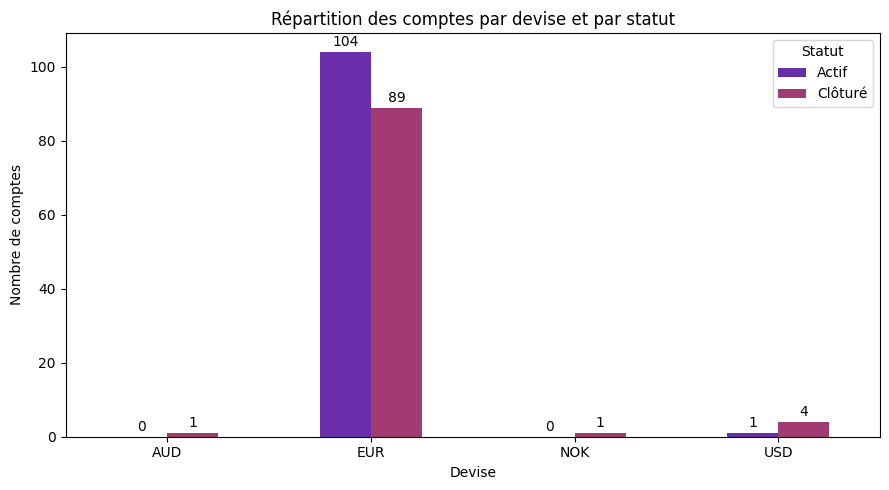

In [63]:
# Visualisation du nombre de comptes par devise et par statut
ax = tableau_de_bord.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#6A2EAB", "#A23B72"]
)

ax.set_title("Répartition des comptes par devise et par statut")
ax.set_xlabel("Devise")
ax.set_ylabel("Nombre de comptes")
ax.legend(title="Statut")
ax.tick_params(axis="x", rotation=0)

for conteneur in ax.containers:
    ax.bar_label(conteneur, fmt="%.0f", padding=2)

ax.figure.tight_layout()

In [64]:
# pd.crosstab() fait la même chose, en plus simple à écrire, pour un simple comptage croisé
pd.crosstab(tie["COD_LNG_CTR"], tie["TYPE_CLIENT"])

TYPE_CLIENT,Entreprise,Particulier
COD_LNG_CTR,,
FR,1,66
NL,0,33


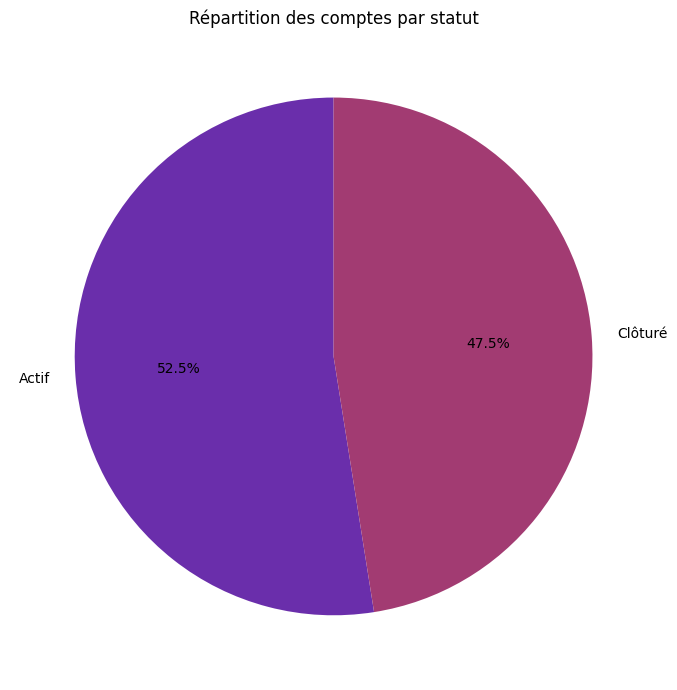

In [66]:
# Additionne les comptes de chaque statut, toutes devises confondues.
comptes_par_statut = tableau_de_bord.sum(axis=0)

# Crée le camembert à partir des nombres de comptes par statut.
ax_camembert = comptes_par_statut.plot(
    kind="pie",                         # Demande un graphique en secteurs.
    figsize=(7, 7),                     # Définit la taille du graphique.
    autopct="%.1f%%",                   # Affiche le pourcentage avec une décimale.
    startangle=90,                      # Commence le premier secteur en haut.
    colors=["#6A2EAB", "#A23B72"],      # Définit une couleur par statut.
    ylabel=""                           # Supprime le nom de l'axe vertical.
)

# Ajoute un titre explicite au graphique.
ax_camembert.set_title("Répartition des comptes par statut")

# Force une forme circulaire au camembert.
ax_camembert.set_aspect("equal")

# Ajuste automatiquement les marges du graphique.
ax_camembert.figure.tight_layout()

In [68]:
# Étape 1 : On calcule le taux de comptes actifs
# == "Actif" crée un tableau de True (vrai) et False (faux)
# .mean() calcule la moyenne : en informatique True vaut 1 et False vaut 0, cela donne donc le pourcentage
taux_actifs = (ctr["STATUT_COMPTE"] == "Actif").mean() * 100

# Étape 2 : On affiche le résultat à l'écran
# :.1f sert à afficher un seul chiffre après la virgule pour plus de clarté
print(f"Taux de comptes actifs sur l'ensemble du portefeuille : {taux_actifs:.1f} %")


Taux de comptes actifs sur l'ensemble du portefeuille : 52.5 %


**Ce que ça veut dire pour la banque :** la direction voit en un coup d'œil la répartition
des comptes. Ce tableau peut être reproduit chaque mois avec le même code : il suffit de
relancer les cellules sur un fichier plus récent.

---
## Situation 12 — "Un audit externe arrive la semaine prochaine"

Un organisme de contrôle va vérifier la qualité des données de la banque. Avant leur
venue, le responsable conformité veut un petit rapport : y a-t-il des doublons ? Des
erreurs de cohérence ?

In [69]:
tables = {"ctr": ctr, "tie": tie, "adr": adr, "lnk": lnk, "txn": txn}

# on vérifie, pour chaque table, s'il y a des lignes strictement identiques (doublons)
for nom, table in tables.items():
    print(f"{nom} : {table.duplicated().sum()} doublon(s)")

ctr : 0 doublon(s)
tie : 0 doublon(s)
adr : 0 doublon(s)
lnk : 0 doublon(s)
txn : 0 doublon(s)


In [70]:
# on vérifie que la clé IDT_AC (identifiant compte) n'est jamais dupliquée : c'est une règle absolue
doublons_cle = ctr["IDT_AC"].duplicated().sum()
print(f"Doublons sur la clé IDT_AC : {doublons_cle}")

Doublons sur la clé IDT_AC : 0


In [71]:
# on vérifie une règle de bon sens : un compte ne peut pas être clôturé AVANT d'avoir été ouvert
comptes_incoherents = ctr[ctr["DAT_CLO_CTR"] < ctr["DAT_OUV_CTR"]]
print(f"Comptes avec une date de clôture avant leur ouverture : {comptes_incoherents.shape[0]}")

Comptes avec une date de clôture avant leur ouverture : 0


In [72]:
def rapport_qualite(table, nom):
    """Construit un petit résumé qualité pour une table : lignes, doublons, taux de complétude."""
    return {
        "table": nom,
        "nb_lignes": table.shape[0],
        "doublons": table.duplicated().sum(),
        "taux_completude_pct": round((1 - table.isna().mean().mean()) * 100, 1),
    }

rapport = pd.DataFrame([rapport_qualite(t, nom) for nom, t in tables.items()])
rapport

,table,nb_lignes,doublons,taux_completude_pct
0,ctr,200,0,73.7
1,tie,100,0,99.7
2,adr,100,0,79.9
3,lnk,200,0,95.4
4,txn,1260,0,89.0


In [ ]:
# Graphique du taux de complétude de chaque table
# Le taux de complétude indique le pourcentage d'informations renseignées.

ax_qualite = rapport.plot(
    x="table",
    y="taux_completude_pct",
    kind="bar",
    figsize=(8, 5),
    color="#6A2EAB",
    legend=False
)

# Ajout d'un titre et de noms d'axes clairs
ax_qualite.set_title("Taux de complétude des tables")
ax_qualite.set_xlabel("Table")
ax_qualite.set_ylabel("Complétude (%)")

# L'axe vertical va de 0 à 100 %
ax_qualite.set_ylim(0, 100)

# Affichage de la valeur au-dessus de chaque barre
for barre in ax_qualite.containers:
    ax_qualite.bar_label(barre, fmt="%.1f%%", padding=3)

# Ajustement automatique de la présentation
ax_qualite.figure.tight_layout()

**Ce que ça veut dire pour la banque :** ce rapport peut être montré directement à
l'auditeur. Il n'y a pas de doublon ni d'incohérence de date sur cet extrait, ce qui est
un bon point. Le taux de complétude montre, table par table, où il manque le plus
d'informations.

---
## Situation 13 — "Un stagiaire a peut-être mal fusionné deux fichiers Excel"

Un stagiaire a préparé un export et n'est pas sûr de son travail : *"Je crois qu'il y a
des soldes bizarres dans mon fichier, est-ce que tu peux vérifier ?"*

In [ ]:
# Une méthode classique pour repérer des valeurs "anormales" : la méthode de l'écart interquartile (IQR)
# .quantile(0.25) et .quantile(0.75) découpent les données en 4 groupes égaux
q1 = ctr["SLD_CTR"].quantile(0.25)
q3 = ctr["SLD_CTR"].quantile(0.75)
ecart = q3 - q1

borne_basse = q1 - 1.5 * ecart
borne_haute = q3 + 1.5 * ecart

valeurs_etranges = ctr[(ctr["SLD_CTR"] < borne_basse) | (ctr["SLD_CTR"] > borne_haute)]
print(f"Bornes normales : entre {borne_basse:.2f} et {borne_haute:.2f}")
print(f"Nombre de soldes jugés 'anormaux' par cette méthode : {valeurs_etranges.shape[0]}")

In [ ]:
# .describe() donne un résumé statistique complet en une seule fois : bon réflexe avant de conclure trop vite
ctr["SLD_CTR"].describe()

**Ce que ça veut dire pour la banque :** attention ! Ici, beaucoup de soldes valent 0 ou
sont manquants, ce qui écrase la méthode statistique autour de 0 : elle signale presque
tout compte avec un solde non nul comme "anormal". Ce n'est pas forcément une erreur du
stagiaire : c'est une limite de la méthode sur des données très concentrées. Une vraie
vérification demande toujours de discuter avec le métier, pas seulement de faire un
calcul automatique.

---
## Situation 14 — "Il me faut un tableau propre pour une présentation"

Le manager prépare une présentation PowerPoint pour ses supérieurs. Il vous demande un
petit tableau propre, avec des noms de colonnes compréhensibles, prêt à copier-coller.

In [ ]:
# on choisit seulement les colonnes utiles pour la présentation
tableau_presentation = ctr[["IDT_AC", "STATUT_COMPTE", "COD_DEV", "DAT_OUV_CTR", "SLD_CTR"]].copy()

# .rename() donne des noms de colonnes plus clairs, faciles à comprendre pour un non-spécialiste
tableau_presentation = tableau_presentation.rename(columns={
    "IDT_AC": "Numéro de compte",
    "STATUT_COMPTE": "Statut",
    "COD_DEV": "Devise",
    "DAT_OUV_CTR": "Date d'ouverture",
    "SLD_CTR": "Solde (EUR)",
})

# on trie par solde décroissant : les plus gros comptes en premier, plus parlant pour une présentation
tableau_presentation = tableau_presentation.sort_values("Solde (EUR)", ascending=False)

tableau_presentation.head(10)

In [ ]:
# .to_csv() enregistre le tableau dans un fichier, prêt à être ouvert dans Excel
tableau_presentation.to_csv("tableau_pour_presentation.csv", sep=";", index=False)
print("Fichier enregistré : tableau_pour_presentation.csv")

**Ce que ça veut dire pour la banque :** le manager peut ouvrir ce fichier directement dans
Excel et le coller dans sa présentation, sans avoir à comprendre les noms de colonnes
techniques du système bancaire d'origine.

---
## Situation 15 — "Avant de partir, fais-moi un dernier résumé de tout"

C'est la fin de votre mission. Votre chef d'équipe vous demande un dernier résumé global :
*"Donne-moi les chiffres clés de tout ce qu'on a regardé cette semaine, en une seule
page."*

In [ ]:
# pd.concat() empile plusieurs tableaux les uns sur les autres (contrairement à merge, qui les met côte à côte)
# ici, un petit exemple : on empile les 3 plus gros comptes EUR et les 3 plus gros comptes USD
top_eur = ctr[ctr["COD_DEV"] == "EUR"].nlargest(3, "SLD_CTR")
top_usd = ctr[ctr["COD_DEV"] == "USD"].nlargest(3, "SLD_CTR")
top_par_devise = pd.concat([top_eur, top_usd])
top_par_devise[["IDT_AC", "COD_DEV", "SLD_CTR"]]

In [ ]:
# on construit le résumé final, avec une ligne par indicateur clé (un "KPI")
resume_final = pd.Series({
    "Nombre de clients": tie.shape[0],
    "Nombre de comptes": ctr.shape[0],
    "Comptes actifs": (ctr["STATUT_COMPTE"] == "Actif").sum(),
    "Comptes en découvert": (ctr["SLD_CTR"] < 0).sum(),
    "Montant total en découvert (EUR)": ctr.loc[ctr["SLD_CTR"] < 0, "SLD_CTR"].sum().round(2),
    "Nombre d'opérations enregistrées": txn.shape[0],
    "Clients sans aucun contact connu": injoignables.shape[0],
})
resume_final

In [ ]:
resume_final.to_csv("resume_final_mission.csv", header=["valeur"])   # on enregistre aussi ce résumé
print("Résumé enregistré : resume_final_mission.csv")
print()
print("Fin de la mission. Vous avez pratiqué : chargement, nettoyage, filtrage, dates,")
print("texte, valeurs manquantes, groupby, fusion de tables, tableaux croisés,")
print("détection d'anomalies, export, et l'écriture de vos propres fonctions.")

**Ce que ça veut dire pour la banque :** ce résumé tient sur une seule page, mais il
raconte toute l'histoire de la semaine : combien de clients, combien de comptes, combien
sont à risque, et combien de travail reste à faire (les clients injoignables, par
exemple). C'est exactement ce qu'un chef d'équipe attend en fin de mission : des chiffres
clairs, pas juste du code.